# PS4 — Scalable anomaly, outlier and clustering pipeline

**Purpose.** Score device-day behaviour from the hourly PS4 Gold source,
combine adaptive statistical signals with distributed clustering, and
publish a compact, idempotent weekly feed for Lambda → RDS.

## Design guarantees

- no Pandas collection of the full hourly, train, or test data;
- all model thresholds are learned from data strictly before the scoring
  period (no validation/test leakage);
- clustering is performed separately for TVM, GATE, and VALIDATOR;
- a cluster is an operating mode, not automatically an anomaly;
- output is versioned in S3. A `READY.json` manifest is written last and
  is the only object that should trigger the Lambda loader;
- the normal run publishes only completed weeks and reprocesses a small
  number of recent weeks for late-arriving source records.

**Important:** run this in a prepared SageMaker kernel/image. Do not run
package installation cells during every production execution.


## One-time environment setup

Use a dedicated SageMaker image or lifecycle configuration with a
compatible Java 17 + Spark environment. This notebook intentionally
avoids `pip install --upgrade` and `conda install` during a run because
that is slow and can change the Spark/Hadoop dependency set.

Required libraries: `pyspark`, `boto3`, `pandas`, `matplotlib`, and
optionally `mlflow`. The code uses native Spark ML only; it does not
install or run sklearn Isolation Forest, DBSCAN, or LOF on the full data.

If Cell 1 reports that PySpark is missing, run the next **one-time
bootstrap cell**, restart the kernel when it asks, then run the notebook
from the beginning. The normal path does not reinstall packages.


In [1]:
# CELL 0 — One-time SageMaker Spark bootstrap (run only if this kernel lacks PySpark/Java)
# This notebook uses local Spark on the SageMaker instance. Spark 4.2.0
# supports Python 3.12 and requires Java 17+.
import importlib.util
import os
import shutil
import subprocess
import sys

PYSPARK_VERSION = "4.2.0"
restart_required = False

if importlib.util.find_spec("pyspark") is None:
    print(f"Installing PySpark {PYSPARK_VERSION} into the current SageMaker kernel...")
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "--no-cache-dir",
        f"pyspark=={PYSPARK_VERSION}",
    ])
    restart_required = True


def discover_java_home():
    candidates = [
        os.environ.get("JAVA_HOME"),
        "/opt/conda/lib/jvm",
        "/usr/lib/jvm/java-17-amazon-corretto",
        "/usr/lib/jvm/java-17-openjdk",
    ]
    java_from_path = shutil.which("java")
    if java_from_path:
        candidates.append(os.path.dirname(os.path.dirname(os.path.realpath(java_from_path))))
    for candidate in candidates:
        if candidate and os.path.isfile(os.path.join(candidate, "bin", "java")):
            return os.path.realpath(candidate)
    return None


java_home = discover_java_home()
if java_home is None:
    conda_exe = shutil.which("conda")
    if conda_exe is None:
        raise RuntimeError(
            "PySpark also needs Java 17. Install OpenJDK 17 in this SageMaker image, then restart the kernel."
        )
    print("Installing OpenJDK 17 once into the current conda environment...")
    subprocess.check_call([conda_exe, "install", "-y", "-c", "conda-forge", "openjdk=17"])
    restart_required = True
    java_home = discover_java_home()

if java_home:
    os.environ["JAVA_HOME"] = java_home
    os.environ["PATH"] = os.path.join(java_home, "bin") + os.pathsep + os.environ.get("PATH", "")

if restart_required:
    raise RuntimeError(
        "One-time PySpark/Java installation completed. Restart the SageMaker kernel, then run this notebook from Cell 0."
    )

import pyspark
print(f"PySpark {pyspark.__version__}; JAVA_HOME={os.environ.get('JAVA_HOME')}")


PySpark 4.2.0; JAVA_HOME=/opt/conda/lib/jvm


In [2]:
# CELL 1 — Imports and environment guard
import json
import os
import uuid
from datetime import date, datetime, timedelta, timezone

import boto3
import pandas as pd
import matplotlib.pyplot as plt

from pyspark import StorageLevel
from pyspark.ml import Pipeline
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.ml.feature import Imputer, StandardScaler, VectorAssembler
from pyspark.ml.functions import vector_to_array
from pyspark.sql import SparkSession, Window
from pyspark.sql import functions as F

try:
    import mlflow
    MLFLOW_AVAILABLE = True
except Exception:
    MLFLOW_AVAILABLE = False

print("Imports OK")
print(f"MLflow available: {MLFLOW_AVAILABLE}")


Imports OK
MLflow available: True


In [3]:
# CELL 2 — Configuration
# Keep this explicit: it lets Spark prune source partitions instead of
# scanning the full Gold history to find MAX.  For a scheduled run, set
# PS4_AS_OF_DATE (YYYY-MM-DD) in the job environment.  The fallback is
# the latest fully landed Gold day observed in the supplied run log.
AS_OF_DATE = os.environ.get("PS4_AS_OF_DATE", "2026-04-11")
RUN_MODE = "incremental"  # "incremental" (normal) or "backfill" (one-time history load)

# Deploy-specific values come from the job environment so the same notebook
# serves a scheduled job and the Boston port without edits. Defaults are
# today's Chicago dev values - a run with no env set behaves exactly as before.
#   PS4_CITY_CODE / PS4_CITY_NAME / PS4_ARTIFACT_BUCKET / PS4_GOLD_PREFIX
CITY_CODE = os.environ.get("PS4_CITY_CODE", "CHI")
CITY_NAME = os.environ.get("PS4_CITY_NAME", "chicago")
ARTIFACT_BUCKET = os.environ.get(
    "PS4_ARTIFACT_BUCKET", "cubic-mars-pm-s3-datalake-dev-artifacts-170202974600"
)
GOLD_BUCKET = "cubic-mars-pm-s3-datalake-dev-gold-170202974600"
GOLD_PREFIX = os.environ.get("PS4_GOLD_PREFIX", "chicago/gold/device_ps4_hourly")
GOLD_S3 = f"s3://{GOLD_BUCKET}/{GOLD_PREFIX}"

# New root by default: the legacy PS4 output remains untouched until the
# revised feed has been accepted.
# PIPELINE_VERSION stays a code constant on purpose: it names the output
# family under OUTPUT_ROOT, and letting a job env change it would silently
# fork the dataset the loader and dashboards read. Bump it here, in review.
PIPELINE_VERSION = "v3"
OUTPUT_ROOT = f"s3://{ARTIFACT_BUCKET}/{CITY_NAME}/ps4/{PIPELINE_VERSION}"
ENABLE_S3_PUBLISH = True
PUBLISH_MODE = "versioned"  # safe default; never delete/overwrite old snapshots
PROMOTE_LATEST_MANIFEST = True

# Incremental processing and leakage-safe modelling windows.
CLUSTER_TRAIN_LOOKBACK_DAYS = 365
SCORING_LOOKBACK_DAYS = 28
REPROCESS_CLOSED_WEEKS = 2
BACKFILL_START_DATE = "2023-07-01"  # used only when RUN_MODE == "backfill"
MIN_OBSERVED_HOURS_PER_DAY = 4
MIN_BASELINE_OBSERVATIONS = 8

# Gold device_ps4_hourly is a governed device-hour dataset.  Do not
# re-aggregate its entire history merely to check uniqueness.  Enable
# this bounded audit when the upstream data contract is being changed.
VERIFY_RECENT_HOURLY_DUPLICATES = False
RECENT_DUPLICATE_AUDIT_DAYS = 7

# Clustering is tuned on a bounded deterministic sample and then fitted
# once per device category on a larger bounded sample.
K_CANDIDATES = [3, 4, 5, 6]
K_TUNING_ROWS_PER_TYPE = 50_000
K_TRAIN_ROWS_PER_TYPE = 300_000
CLUSTER_TAIL_QUANTILE = 0.99
RARE_CLUSTER_SHARE = 0.005
RANDOM_SEED = 20260729

# S3 output and Lambda/RDS contract.
MAX_RECORDS_PER_FILE = 100_000
WEEK_START_DAY = "Monday"  # Spark date_trunc('week', ...) follows Monday.
OUTPUT_DATASETS = ["weekly_device_summary", "weekly_alerts", "weekly_timeline", "cluster_profile"]
RUN_ID = f"ps4-{datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%SZ')}-{uuid.uuid4().hex[:8]}"

# Optional MLflow tracking. Keep it off rather than making the data
# pipeline fail because a tracking server is temporarily unavailable.
ENABLE_MLFLOW = False
MLFLOW_TRACKING_SERVER_ARN = (
    "arn:aws:sagemaker:us-east-1:170202974600:"
    "mlflow-tracking-server/cubic-mars-mlflow-server-dev"
)
MLFLOW_EXPERIMENT = "chicago-ps4-anomaly-clustering-v3"

# Data-contract candidates. The notebook resolves whichever canonical
# names exist in Gold and raises a clear error for missing essentials.
DEVICE_ID_CANDIDATES = ["DEVICE_ID", "device_id", "ncs_device_id"]
DEVICE_TYPE_CANDIDATES = ["mars_device_category", "device_type", "device_category"]
HOUR_CANDIDATES = ["hour_dt", "hour_bucket", "event_hour", "timestamp_hour"]
TRANSIT_DAY_CANDIDATES = ["transit_day", "service_day", "operational_day"]
FACILITY_CANDIDATES = ["FACILITY_ID", "facility_id", "station_id", "stop_point_id"]
METRIC_CANDIDATES = {
    "event_count": ["event_count_hour", "event_count", "events_hour"],
    "tap_reject_count": ["tap_reject_count_hour", "reject_count_hour", "tap_reject_count"],
    "tap_attempt_count": ["tap_count_hour", "tap_attempt_count_hour", "tap_attempt_count"],
    "latency_ms": ["metric_401_avg_ms_hour", "response_time_ms_hour", "latency_ms_hour"],
    "oos_count": ["oos_count_hour", "out_of_service_count_hour"],
    "hardware_count": ["bhu_count_hour", "chu_count_hour", "printer_count_hour"],
    "revenue": ["use_revenue_hour", "revenue_hour", "revenue_amount_hour"],
}

print(f"Gold source : {GOLD_S3}")
print(f"Output root : {OUTPUT_ROOT}")
print(f"Run id      : {RUN_ID}")


Gold source : s3://cubic-mars-pm-s3-datalake-dev-gold-170202974600/chicago/gold/device_ps4_hourly
Output root : s3://cubic-mars-pm-s3-datalake-dev-artifacts-170202974600/chicago/ps4/v3
Run id      : ps4-20260728T213153Z-bf4609d4


In [4]:
# CELL 3 — Spark session: memory-aware local Spark, with the S3A connector
# PySpark from PyPI does not bundle Hadoop's optional S3A connector.
# This SageMaker PySpark 4.2.0 runtime reports Hadoop 3.5.0, so the
# exact matching hadoop-aws package is resolved before Spark starts.
#
# IMPORTANT: driver heap and package classpath are fixed when the first
# SparkContext is created.  After a Java OOM or after changing this
# cell, restart the kernel and run from Cell 0 before running Cell 3.
from pyspark import SparkContext

if SparkContext._active_spark_context is not None:
    raise RuntimeError(
        "A SparkContext already exists, so its JVM heap and S3A classpath cannot be resized safely. "
        "Restart the kernel, then run Cells 0–3 in order."
    )

def memory_limit_bytes():
    # Prefer the container/cgroup limit used by SageMaker kernels; fall
    # back to host RAM only when no cgroup limit is available.
    for path in ("/sys/fs/cgroup/memory.max", "/sys/fs/cgroup/memory/memory.limit_in_bytes"):
        try:
            with open(path, "r", encoding="utf-8") as handle:
                raw_limit = handle.read().strip()
            if raw_limit and raw_limit != "max":
                limit = int(raw_limit)
                if 0 < limit < (1 << 60):
                    return limit
        except (OSError, ValueError):
            pass
    try:
        return os.sysconf("SC_PAGE_SIZE") * os.sysconf("SC_PHYS_PAGES")
    except (AttributeError, OSError, ValueError):
        return None

memory_bytes = memory_limit_bytes()
available_memory_gb = max(1, int(memory_bytes // (1024 ** 3))) if memory_bytes else 16
logical_cores = os.cpu_count() or 4
# Limiting concurrent tasks on smaller instances avoids 15–16 hash
# aggregations competing for the same local JVM heap.
local_threads = max(2, min(logical_cores, 16, max(2, available_memory_gb // 2)))
driver_memory_gb = max(2, min(96, int(available_memory_gb * 0.60)))
shuffle_partitions = max(128, min(local_threads * 16, 1024))
INPUT_REPARTITIONS = shuffle_partitions
HADOOP_AWS_VERSION = "3.5.0"
S3A_JAR_PACKAGE = f"org.apache.hadoop:hadoop-aws:{HADOOP_AWS_VERSION}"
SPARK_IVY_DIR = os.path.join(os.path.expanduser("~"), ".ivy2")

spark = (
    SparkSession.builder
    .appName("PS4-Scalable-Anomaly-Clustering-v3")
    .master(os.environ.get("PS4_SPARK_MASTER", f"local[{local_threads}]"))
    .config("spark.driver.memory", f"{driver_memory_gb}g")
    .config("spark.executor.memory", f"{driver_memory_gb}g")
    .config("spark.driver.maxResultSize", f"{max(1, min(8, driver_memory_gb // 4))}g")
    .config("spark.jars.packages", S3A_JAR_PACKAGE)
    .config("spark.jars.ivy", SPARK_IVY_DIR)
    .config("spark.hadoop.fs.s3a.impl", "org.apache.hadoop.fs.s3a.S3AFileSystem")
    .config("spark.hadoop.fs.AbstractFileSystem.s3a.impl", "org.apache.hadoop.fs.s3a.S3A")
    .config("spark.sql.adaptive.enabled", "true")
    # Keep the explicit pre-aggregation repartition below intact.
    .config("spark.sql.adaptive.coalescePartitions.enabled", "false")
    .config("spark.sql.adaptive.skewJoin.enabled", "true")
    .config("spark.sql.shuffle.partitions", str(shuffle_partitions))
    .config("spark.sql.files.maxPartitionBytes", str(32 * 1024 * 1024))
    .config("spark.sql.files.minPartitionNum", str(INPUT_REPARTITIONS))
    .config("spark.memory.fraction", "0.70")
    .config("spark.shuffle.sort.bypassMergeThreshold", "100")
    .config("spark.sql.files.maxRecordsPerFile", str(MAX_RECORDS_PER_FILE))
    .config("spark.sql.parquet.compression.codec", "zstd")
    .config("spark.sql.parquet.filterPushdown", "true")
    .config("spark.sql.session.timeZone", "UTC")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")

runtime_hadoop_version = spark._jvm.org.apache.hadoop.util.VersionInfo.getVersion()
if runtime_hadoop_version != HADOOP_AWS_VERSION:
    spark.stop()
    raise RuntimeError(
        f"Spark runtime Hadoop version is {runtime_hadoop_version}, but hadoop-aws {HADOOP_AWS_VERSION} was requested. "
        "Update HADOOP_AWS_VERSION to the exact runtime Hadoop version, restart the kernel, and rerun from Cell 0."
    )
try:
    # Do not use java.lang.Class.forName here: in local PySpark it uses
    # the system classloader, while --packages jars live on Spark's
    # user-jar classloader. Hadoop's resolver is the same code path
    # used later by spark.read.parquet(s3a://...).
    hadoop_conf = spark.sparkContext._jsc.hadoopConfiguration()
    s3a_filesystem_class = spark._jvm.org.apache.hadoop.fs.FileSystem.getFileSystemClass("s3a", hadoop_conf)
    s3a_class_name = s3a_filesystem_class.getName()
except Exception as exc:
    spark.stop()
    raise RuntimeError(
        "S3A connector did not load. Restart the kernel and rerun Cell 3. "
        f"If it persists, confirm this SageMaker environment can resolve Maven package {S3A_JAR_PACKAGE}."
    ) from exc

# Never use the older hadoop-aws 3.3.x / AWS SDK v1 workaround with this
# Spark 4.2 / Hadoop 3.5.0 runtime.
def spark_uri(uri: str) -> str:
    return "s3a://" + uri[len("s3://"):] if uri.startswith("s3://") else uri

print(
    f"Spark {spark.version}; Hadoop {runtime_hadoop_version}; S3A={s3a_class_name}; "
    f"master={spark.sparkContext.master}; host_cores={logical_cores}; local_threads={local_threads}; "
    f"memory_limit≈{available_memory_gb}g; driver_heap={driver_memory_gb}g; partitions={shuffle_partitions}"
)
if available_memory_gb < 32:
    print("[WARN] Less than 32 GiB is visible to this kernel. Use ml.r5.4xlarge (128 GiB) for the full 365-day production run.")


:: loading settings :: url = jar:file:/opt/conda/lib/python3.12/site-packages/pyspark/jars/ivy-2.5.3.jar!/org/apache/ivy/core/settings/ivysettings.xml
Ivy Default Cache set to: /home/sagemaker-user/.ivy2/cache
The jars for the packages stored in: /home/sagemaker-user/.ivy2/jars
org.apache.hadoop#hadoop-aws added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-7b7c0e29-1b78-4918-a5b7-cada7a171a20;1.0
	confs: [default]
	found org.apache.hadoop#hadoop-aws;3.5.0 in central


	found software.amazon.awssdk#bundle;2.35.4 in central
	found software.amazon.s3.analyticsaccelerator#analyticsaccelerator-s3;1.3.1 in central
	found org.wildfly.openssl#wildfly-openssl;2.2.5.Final in central
:: resolution report :: resolve 181ms :: artifacts dl 6ms
	:: modules in use:
	org.apache.hadoop#hadoop-aws;3.5.0 from central in [default]
	org.wildfly.openssl#wildfly-openssl;2.2.5.Final from central in [default]
	software.amazon.awssdk#bundle;2.35.4 from central in [default]
	software.amazon.s3.analyticsaccelerator#analyticsaccelerator-s3;1.3.1 from central in [default]
	---------------------------------------------------------------------
	|                  |            modules            ||   artifacts   |
	|       conf       | number| search|dwnlded|evicted|| number|dwnlded|
	---------------------------------------------------------------------
	|      default     |   4   |   0   |   0   |   0   ||   4   |   0   |
	-----------------------------------------------------------

26/07/28 21:31:55 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


Spark 4.2.0; Hadoop 3.5.0; S3A=org.apache.hadoop.fs.s3a.S3AFileSystem; master=local[16]; host_cores=16; local_threads=16; memory_limit≈62g; driver_heap=37g; partitions=256


In [5]:
# CELL 4 — Utilities: data contract, safe scalar conversions, and dates
def first_existing(columns, candidates, required=False, label="column"):
    found = next((c for c in candidates if c in columns), None)
    if found is None and required:
        raise ValueError(f"Missing required {label}. Expected one of {candidates}; available sample={sorted(columns)[:30]}")
    return found


def as_double_or_null(column_name):
    return F.col(column_name).cast("double") if column_name else F.lit(None).cast("double")


def date_from_config(value):
    if value is None:
        return None
    return datetime.strptime(value, "%Y-%m-%d").date()


def bounded_sample(sdf, n_rows, seed, count_hint=None):
    """Distributed sample; never converts raw data to Pandas."""
    n = count_hint if count_hint is not None else sdf.count()
    if n <= n_rows:
        return sdf
    fraction = min(1.0, max(0.0001, n_rows / float(n)))
    return sdf.sample(withReplacement=False, fraction=fraction, seed=seed).limit(n_rows)


def safe_rate(num_col, den_col):
    return F.when(F.col(den_col) > 0, F.col(num_col) / F.col(den_col)).otherwise(F.lit(None).cast("double"))


def max_abs_z(*columns):
    present = [F.coalesce(F.abs(F.col(c)), F.lit(0.0)) for c in columns]
    return F.greatest(*present) if present else F.lit(0.0)


def null_if_small_std(std_col):
    return F.when(F.col(std_col) > F.lit(1e-9), F.col(std_col))


def log_mlflow_metrics(metrics, params=None):
    if not (ENABLE_MLFLOW and MLFLOW_AVAILABLE):
        return
    try:
        mlflow.set_tracking_uri(MLFLOW_TRACKING_SERVER_ARN)
        mlflow.set_experiment(MLFLOW_EXPERIMENT)
        with mlflow.start_run(run_name=RUN_ID):
            mlflow.set_tags({"ps": "PS4", "city": CITY_CODE, "pipeline_version": PIPELINE_VERSION})
            for k, v in (params or {}).items():
                mlflow.log_param(k, str(v))
            mlflow.log_metrics({k: float(v) for k, v in metrics.items() if v is not None})
    except Exception as exc:
        print(f"[WARN] MLflow logging skipped: {type(exc).__name__}: {exc}")


In [6]:
# CELL 5 — Read Gold once, canonicalise columns, and filter before any wide aggregation
raw = spark.read.parquet(spark_uri(GOLD_S3))
source_columns = set(raw.columns)

source_device_id = first_existing(source_columns, DEVICE_ID_CANDIDATES, required=True, label="device id")
source_device_type = first_existing(source_columns, DEVICE_TYPE_CANDIDATES, required=True, label="device type")
source_hour = first_existing(source_columns, HOUR_CANDIDATES, required=True, label="hour timestamp")
source_transit_day = first_existing(source_columns, TRANSIT_DAY_CANDIDATES, required=False)
source_facility = first_existing(source_columns, FACILITY_CANDIDATES, required=False)
source_metrics = {name: first_existing(source_columns, candidates) for name, candidates in METRIC_CANDIDATES.items()}

selected = [source_device_id, source_device_type, source_hour]
selected += [c for c in [source_transit_day, source_facility, *source_metrics.values()] if c]
raw = raw.select(*dict.fromkeys(selected))

canonical = raw.select(
    F.col(source_device_id).cast("string").alias("device_id"),
    F.upper(F.trim(F.col(source_device_type).cast("string"))).alias("device_type"),
    F.to_timestamp(F.col(source_hour)).alias("hour_dt"),
    (
        F.to_date(F.col(source_transit_day))
        if source_transit_day else F.to_date(F.col(source_hour))
    ).alias("transit_day"),
    (
        F.coalesce(F.col(source_facility).cast("string"), F.lit("UNKNOWN"))
        if source_facility else F.lit("UNKNOWN")
    ).alias("facility_id"),
    *[as_double_or_null(source_metrics[name]).alias(name) for name in source_metrics],
).where(
    F.col("device_id").isNotNull() & F.col("device_type").isNotNull() &
    F.col("hour_dt").isNotNull() & F.col("transit_day").isNotNull()
)

# device_ps4_hourly is already governed at device-hour grain.  A full
# groupBy on device_id + hour_dt has nearly the same cardinality as the
# source and was the main cause of the Java heap exhaustion.  Preserve
# its declared grain and aggregate once, after the time predicate, to
# the deliberately smaller device-day grain in Cell 6.
hourly = canonical
if AS_OF_DATE is None:
    as_of_date = hourly.agg(F.max("transit_day").alias("asof")).first()["asof"]
    print("[INFO] AS_OF_DATE was not set; full source metadata/data scan may have been required.")
else:
    as_of_date = date_from_config(AS_OF_DATE)

if as_of_date is None:
    raise RuntimeError("Gold source contains no valid transit_day values.")

if RUN_MODE not in {"incremental", "backfill"}:
    raise ValueError("RUN_MODE must be 'incremental' or 'backfill'.")

if RUN_MODE == "incremental":
    score_start = as_of_date - timedelta(days=SCORING_LOOKBACK_DAYS - 1)
    train_end = score_start - timedelta(days=1)
    train_start = train_end - timedelta(days=CLUSTER_TRAIN_LOOKBACK_DAYS - 1)
    process_start = train_start
else:
    # One-time historical backfill: fit only on the initial training
    # window and score all later weeks. Production runs should remain
    # incremental so their baselines are refreshed regularly.
    process_start = date_from_config(BACKFILL_START_DATE)
    train_start = process_start
    train_end = min(
        train_start + timedelta(days=CLUSTER_TRAIN_LOOKBACK_DAYS - 1),
        as_of_date - timedelta(days=1),
    )
    score_start = train_end + timedelta(days=1)
    if score_start > as_of_date:
        raise RuntimeError("Backfill needs more than CLUSTER_TRAIN_LOOKBACK_DAYS of source history.")
# This predicate is intentionally below the timestamp parsing but above
# every shuffle.  If transit_day is a Gold partition column, Spark can
# prune most of the source before it reads Parquet files.
hourly = hourly.where((F.col("transit_day") >= F.lit(process_start)) & (F.col("transit_day") <= F.lit(as_of_date)))
if hourly.limit(1).count() == 0:
    raise RuntimeError(f"No hourly data in selected period {process_start} to {as_of_date}.")
if VERIFY_RECENT_HOURLY_DUPLICATES:
    duplicate_audit_start = max(process_start, as_of_date - timedelta(days=RECENT_DUPLICATE_AUDIT_DAYS - 1))
    duplicate_found = (
        hourly.where(F.col("transit_day") >= F.lit(duplicate_audit_start))
        .groupBy("device_id", "device_type", "facility_id", "hour_dt", "transit_day")
        .count().where(F.col("count") > 1).limit(1).count()
    )
    if duplicate_found:
        raise RuntimeError(
            "Duplicate device-hour rows were found in the bounded audit window. "
            "Fix the Gold data contract before enabling this production run."
        )
print(json.dumps({"as_of_date": str(as_of_date), "train": [str(train_start), str(train_end)], "score": [str(score_start), str(as_of_date)], "duplicate_audit_enabled": VERIFY_RECENT_HOURLY_DUPLICATES}, default=str, indent=2))


SLF4J: Failed to load class "org.slf4j.impl.StaticLoggerBinder".
SLF4J: Defaulting to no-operation (NOP) logger implementation
SLF4J: See http://www.slf4j.org/codes.html#StaticLoggerBinder for further details.


{
  "as_of_date": "2026-04-11",
  "train": [
    "2025-03-15",
    "2026-03-14"
  ],
  "score": [
    "2026-03-15",
    "2026-04-11"
  ],
  "duplicate_audit_enabled": false
}


In [7]:
# CELL 6 — Compact hourly observations to device-day features before modelling
# Repartition *before* the hash aggregation.  The source has only a
# small number of large Parquet partitions; without this exchange, each
# task builds an oversized device-day hash map and can exhaust the JVM.
daily_input = hourly.repartition(INPUT_REPARTITIONS, "device_id", "transit_day")
daily = (
    daily_input.groupBy("device_id", "device_type", "facility_id", "transit_day")
    .agg(
        F.count("*").alias("observed_hours"),
        F.sum("event_count").alias("event_count"),
        F.sum("tap_reject_count").alias("tap_reject_count"),
        F.sum("tap_attempt_count").alias("tap_attempt_count"),
        F.avg("latency_ms").alias("latency_ms"),
        F.sum("oos_count").alias("oos_count"),
        F.sum("hardware_count").alias("hardware_count"),
        F.sum("revenue").alias("revenue"),
    )
    .withColumn("event_log", F.log1p(F.greatest(F.coalesce(F.col("event_count"), F.lit(0.0)), F.lit(0.0))))
    .withColumn("tap_reject_rate", safe_rate("tap_reject_count", "tap_attempt_count"))
    .withColumn("oos_rate", safe_rate("oos_count", "observed_hours"))
    .withColumn("hardware_rate", safe_rate("hardware_count", "observed_hours"))
    .withColumn("low_coverage_day", (F.col("observed_hours") < F.lit(MIN_OBSERVED_HOURS_PER_DAY)).cast("int"))
    .withColumn("day_of_week", F.dayofweek("transit_day"))
    .persist(StorageLevel.DISK_ONLY)
)

daily_profile = daily.agg(
    F.count("*").alias("device_days"),
    F.sum("observed_hours").alias("device_hour_rows"),
    F.approx_count_distinct("device_id", rsd=0.02).alias("approx_devices"),
    F.min("transit_day").alias("min_day"),
    F.max("transit_day").alias("max_day"),
    F.avg("observed_hours").alias("avg_observed_hours"),
    F.mean("low_coverage_day").alias("low_coverage_day_rate"),
).first().asDict()
# Preserve the manifest/dashboard shape without triggering a second
# full scan of hourly Gold.  The device count is deliberately
# approximate (2% RSD) because it is an operational profile, not an
# RDS key or modelling feature.
source_profile = {
    "device_hour_rows": daily_profile["device_hour_rows"],
    "devices": daily_profile["approx_devices"],
    "min_day": daily_profile["min_day"],
    "max_day": daily_profile["max_day"],
}
print("Daily profile:", json.dumps(daily_profile, default=str, indent=2))

train_daily = daily.where((F.col("transit_day") >= F.lit(train_start)) & (F.col("transit_day") <= F.lit(train_end))).persist(StorageLevel.DISK_ONLY)
score_daily = daily.where((F.col("transit_day") >= F.lit(score_start)) & (F.col("transit_day") <= F.lit(as_of_date))).persist(StorageLevel.DISK_ONLY)
if train_daily.limit(1).count() == 0 or score_daily.limit(1).count() == 0:
    raise RuntimeError("Training or scoring period is empty. Check AS_OF_DATE, Gold partitions, and lookback settings.")


26/07/28 21:32:10 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


Daily profile: {
  "device_days": 1378376,
  "device_hour_rows": 14817096,
  "approx_devices": 4415,
  "min_day": "2025-03-15",
  "max_day": "2026-04-11",
  "avg_observed_hours": 10.749676430814233,
  "low_coverage_day_rate": 0.11531686564478778
}


In [8]:
# CELL 7 — Leakage-safe adaptive baselines: fit only pre-score train data
# Device + day-of-week captures recurring operating patterns. Device-type
# fallback supports new/sparse devices without borrowing future records.
BASELINE_METRICS = ["event_log", "tap_reject_rate", "latency_ms", "oos_rate", "hardware_rate"]

def fit_baseline(sdf, keys, suffix):
    aggregations = [F.count("*").alias(f"baseline_n_{suffix}")]
    for metric in BASELINE_METRICS:
        aggregations.extend([
            F.avg(metric).alias(f"{metric}_mean_{suffix}"),
            F.stddev_samp(metric).alias(f"{metric}_std_{suffix}"),
        ])
    return sdf.groupBy(*keys).agg(*aggregations)


device_baseline = fit_baseline(train_daily, ["device_id", "device_type", "day_of_week"], "device")
type_baseline = fit_baseline(train_daily, ["device_type", "day_of_week"], "type")

scored = (
    score_daily
    .join(device_baseline, ["device_id", "device_type", "day_of_week"], "left")
    .join(type_baseline, ["device_type", "day_of_week"], "left")
)

for metric in BASELINE_METRICS:
    mean = F.coalesce(
        F.when(F.col("baseline_n_device") >= F.lit(MIN_BASELINE_OBSERVATIONS), F.col(f"{metric}_mean_device")),
        F.col(f"{metric}_mean_type"),
    )
    std = F.coalesce(
        F.when(F.col("baseline_n_device") >= F.lit(MIN_BASELINE_OBSERVATIONS), null_if_small_std(f"{metric}_std_device")),
        null_if_small_std(f"{metric}_std_type"),
    )
    scored = scored.withColumn(f"{metric}_z", F.when(std.isNotNull(), (F.col(metric) - mean) / std))

# Signals are deliberately independent: volume, tap quality, latency,
# availability, and hardware. A normal cluster alone is not an alert.
scored = (
    scored
    .withColumn("signal_event_spc", (F.abs(F.col("event_log_z")) >= 3.0).cast("int"))
    .withColumn("signal_tap_quality", (F.col("tap_reject_rate_z") >= 3.0).cast("int"))
    .withColumn("signal_latency", (F.abs(F.col("latency_ms_z")) >= 3.0).cast("int"))
    .withColumn("signal_oos", (F.col("oos_rate_z") >= 3.0).cast("int"))
    .withColumn("signal_hardware", (F.col("hardware_rate_z") >= 3.0).cast("int"))
)
SIGNAL_COLS = ["signal_event_spc", "signal_tap_quality", "signal_latency", "signal_oos", "signal_hardware"]
scored = scored.withColumn("statistical_signal_count", sum(F.coalesce(F.col(c), F.lit(0)) for c in SIGNAL_COLS))
scored = scored.withColumn("max_abs_z", max_abs_z(*[f"{m}_z" for m in BASELINE_METRICS]))


In [9]:
# CELL 8 — Select healthy clustering features, tune K per device type, and fit distributed KMeans
# DBSCAN/LOF/IsolationForest are useful investigation tools on a sample,
# but do not scale predictably to this production-sized Spark dataset.
candidate_cluster_features = ["event_log", "tap_reject_rate", "latency_ms", "oos_rate", "hardware_rate", "observed_hours"]
train_type_counts = {r["device_type"]: r["n"] for r in train_daily.groupBy("device_type").count().withColumnRenamed("count", "n").collect()}
device_types = [r["device_type"] for r in score_daily.select("device_type").distinct().collect()]
evaluator = ClusteringEvaluator(featuresCol="cluster_features_scaled", predictionCol="cluster_id", metricName="silhouette", distanceMeasure="squaredEuclidean")
cluster_models = {}
cluster_metrics = []
scored_by_type = []
CLUSTER_FEATURES_BY_TYPE = {}

for idx, device_type in enumerate(sorted(device_types)):
    train_type = train_daily.where(F.col("device_type") == F.lit(device_type))
    train_n = int(train_type_counts.get(device_type, 0))
    if train_n < max(K_CANDIDATES) * 20:
        print(f"[WARN] {device_type}: insufficient training rows ({train_n}) for stable clustering; skipped.")
        continue

    type_feature_health = train_type.agg(*[
        F.stddev_samp(c).alias(f"{c}__std") for c in candidate_cluster_features
    ]).first().asDict()
    type_features = [c for c in candidate_cluster_features if (type_feature_health.get(f"{c}__std") or 0.0) > 1e-9]
    if len(type_features) < 2:
        print(f"[WARN] {device_type}: fewer than two non-constant features; skipped. features={type_features}")
        continue
    CLUSTER_FEATURES_BY_TYPE[device_type] = type_features

    tune = bounded_sample(train_type, K_TUNING_ROWS_PER_TYPE, RANDOM_SEED + idx, train_n)
    imputed = [f"{c}__imp" for c in type_features]
    base_stages = [
        Imputer(inputCols=type_features, outputCols=imputed, strategy="median"),
        VectorAssembler(inputCols=imputed, outputCol="cluster_features_raw", handleInvalid="keep"),
        StandardScaler(inputCol="cluster_features_raw", outputCol="cluster_features_scaled", withMean=True, withStd=True),
    ]

    candidates = []
    for k in K_CANDIDATES:
        tune_pipeline = Pipeline(stages=base_stages + [KMeans(k=k, seed=RANDOM_SEED, featuresCol="cluster_features_scaled", predictionCol="cluster_id", maxIter=40)])
        tune_model = tune_pipeline.fit(tune)
        tune_scored = tune_model.transform(tune)
        silhouette = evaluator.evaluate(tune_scored)
        candidates.append((k, float(silhouette)))

    best_k, best_silhouette = max(candidates, key=lambda x: x[1])
    fit_sample = bounded_sample(train_type, K_TRAIN_ROWS_PER_TYPE, RANDOM_SEED + 100 + idx, train_n)
    final_pipeline = Pipeline(stages=base_stages + [KMeans(k=best_k, seed=RANDOM_SEED, featuresCol="cluster_features_scaled", predictionCol="cluster_id", maxIter=60)])
    final_model = final_pipeline.fit(fit_sample)
    cluster_models[device_type] = final_model

    def add_native_distance(frame, model):
        centers = model.stages[-1].clusterCenters()
        center_array = F.array(*[
            F.array(*[F.lit(float(value)) for value in center]) for center in centers
        ])
        return (
            model.transform(frame)
            .withColumn("cluster_id", F.col("cluster_id").cast("int"))
            .withColumn("_cluster_vector", vector_to_array("cluster_features_scaled"))
            .withColumn("_cluster_centers", center_array)
            .withColumn("_cluster_center", F.element_at(F.col("_cluster_centers"), F.col("cluster_id") + F.lit(1)))
            .withColumn(
                "cluster_distance",
                F.sqrt(F.expr("aggregate(zip_with(_cluster_vector, _cluster_center, (x, y) -> (x-y)*(x-y)), 0D, (acc, x) -> acc + x)")),
            )
            .drop("_cluster_vector", "_cluster_centers", "_cluster_center", "cluster_features_raw", "cluster_features_scaled", *imputed)
        )

    train_clustered = add_native_distance(train_type, final_model)
    cluster_profile = (
        train_clustered.groupBy("cluster_id")
        .agg(
            F.count("*").alias("cluster_train_rows"),
            F.expr(f"percentile_approx(cluster_distance, {CLUSTER_TAIL_QUANTILE}, 10000)").alias("cluster_distance_p99"),
        )
        .withColumn("cluster_share", F.col("cluster_train_rows") / F.lit(float(train_n)))
    )
    score_type = add_native_distance(scored.where(F.col("device_type") == F.lit(device_type)), final_model)
    score_type = score_type.join(cluster_profile, "cluster_id", "left")
    score_type = (
        score_type
        .withColumn("signal_cluster_tail", (F.col("cluster_distance") >= F.col("cluster_distance_p99")).cast("int"))
        .withColumn("signal_rare_cluster", (F.col("cluster_share") < F.lit(RARE_CLUSTER_SHARE)).cast("int"))
        .withColumn("cluster_distance_ratio", F.when(F.col("cluster_distance_p99") > 0, F.col("cluster_distance") / F.col("cluster_distance_p99")))
    )
    scored_by_type.append(score_type)
    cluster_metrics.append({
        "device_type": device_type,
        "selected_k": int(best_k),
        "silhouette": float(best_silhouette),
        "train_rows": train_n,
        "features": type_features,
        "tuning_candidates": candidates,
    })

if not scored_by_type:
    raise RuntimeError("No device category produced a clustering model. Inspect source volume and feature health.")

scored = scored_by_type[0]
for part in scored_by_type[1:]:
    scored = scored.unionByName(part, allowMissingColumns=True)
# Materialise the expensive model-transform/threshold join once; later
# dashboard, weekly, and publish actions reuse this compact scored view.
scored = scored.persist(StorageLevel.DISK_ONLY)
CLUSTER_FEATURES = sorted({feature for values in CLUSTER_FEATURES_BY_TYPE.values() for feature in values})
print("Cluster selection:")
print(pd.DataFrame(cluster_metrics).to_string(index=False))


Cluster selection:
device_type  selected_k  silhouette  train_rows                                             features                                                                                       tuning_candidates
       GATE           3    0.545102      293033    [event_log, latency_ms, oos_rate, observed_hours]    [(3, 0.545101654958621), (4, 0.5055133040711929), (5, 0.45534711423400026), (6, 0.4590482364576577)]
        TVM           5    0.528693      157160 [event_log, oos_rate, hardware_rate, observed_hours]  [(3, 0.37648501759246195), (4, 0.47630593893758266), (5, 0.5286933509465328), (6, 0.4874840921776583)]
  VALIDATOR           3    0.458884      830050    [event_log, latency_ms, oos_rate, observed_hours] [(3, 0.45888420121688844), (4, 0.37932688720095076), (5, 0.4006053679298092), (6, 0.39162822194546065)]


In [10]:
# CELL 9 — Explainable ensemble, persistence logic, and validation metrics
ALL_SIGNAL_COLS = SIGNAL_COLS + ["signal_cluster_tail", "signal_rare_cluster"]
scored = scored.withColumn("signal_count", sum(F.coalesce(F.col(c), F.lit(0)) for c in ALL_SIGNAL_COLS))
scored = scored.withColumn(
    "anomaly_score",
    F.least(
        F.lit(1.0),
        F.lit(0.60) * F.least(F.col("max_abs_z") / F.lit(6.0), F.lit(1.0)) +
        F.lit(0.25) * F.least(F.coalesce(F.col("cluster_distance_ratio"), F.lit(0.0)), F.lit(1.5)) / F.lit(1.5) +
        F.lit(0.15) * F.least(F.col("signal_count") / F.lit(4.0), F.lit(1.0)),
    ),
)
scored = scored.withColumn(
    "candidate_anomaly",
    (
        (F.col("max_abs_z") >= 3.0) |
        (F.col("signal_cluster_tail") == 1) |
        (F.col("signal_rare_cluster") == 1)
    ).cast("int"),
)

persistence_window = Window.partitionBy("device_id", "device_type").orderBy("transit_day").rowsBetween(-2, 0)
scored = scored.withColumn("candidate_days_last_3_observations", F.sum("candidate_anomaly").over(persistence_window))
scored = scored.withColumn(
    "actionable_alert",
    (
        (F.col("signal_count") >= 2) |
        (F.col("max_abs_z") >= 4.0) |
        ((F.col("signal_cluster_tail") == 1) & (F.col("statistical_signal_count") >= 1)) |
        (F.col("candidate_days_last_3_observations") >= 2)
    ).cast("int"),
)
scored = scored.withColumn(
    "severity",
    F.when((F.col("signal_count") >= 3) | ((F.col("anomaly_score") >= 0.85) & (F.col("actionable_alert") == 1)), F.lit("Critical"))
     .when(F.col("actionable_alert") == 1, F.lit("High"))
     .when(F.col("candidate_anomaly") == 1, F.lit("Medium"))
     .otherwise(F.lit("Normal")),
)
scored = scored.withColumn(
    "anomaly_type",
    F.concat_ws(
        "+",
        *[F.when(F.col(c) == 1, F.lit(c.replace("signal_", ""))).otherwise(F.lit(None)) for c in ALL_SIGNAL_COLS],
    ),
)
scored = scored.withColumn("anomaly_type", F.when(F.length("anomaly_type") == 0, F.lit("none")).otherwise(F.col("anomaly_type")))

rate_by_type = (
    scored.groupBy("device_type")
    .agg(
        F.count("*").alias("device_days"),
        F.mean("candidate_anomaly").alias("candidate_rate"),
        F.mean("actionable_alert").alias("actionable_rate"),
        F.mean("low_coverage_day").alias("low_coverage_rate"),
    )
    .orderBy("device_type")
)
print("Scoring health (these are operational rates, not an accuracy claim):")
rate_by_type.show(truncate=False)

# Accuracy/F1 must be evaluated only against independently sourced,
# time-aligned incident/outage labels. This pipeline deliberately does
# not report F1 against a target that contains its own signal.
print("[INFO] No self-referential F1/ROC is calculated. Join validated incidents/outages separately for precision@K, recall@K, lead time, and false-alert rate.")


Scoring health (these are operational rates, not an accuracy claim):


26/07/28 21:34:29 WARN DAGScheduler: Broadcasting large task binary with size 1130.0 KiB


26/07/28 21:34:35 WARN DAGScheduler: Broadcasting large task binary with size 1149.3 KiB


+-----------+-----------+--------------------+--------------------+--------------------+
|device_type|device_days|candidate_rate      |actionable_rate     |low_coverage_rate   |
+-----------+-----------+--------------------+--------------------+--------------------+
|GATE       |22311      |0.06629017076778271 |0.054009233113710725|0.025637577876383846|
|TVM        |12255      |0.07874337005303958 |0.053773969808241534|0.5071399428804569  |
|VALIDATOR  |63567      |0.053644186448943636|0.04041405131593437 |0.08210234870294335 |
+-----------+-----------+--------------------+--------------------+--------------------+

[INFO] No self-referential F1/ROC is calculated. Join validated incidents/outages separately for precision@K, recall@K, lead time, and false-alert rate.


In [11]:
# CELL 10 — Weekly aggregation: compact RDS contract for completed weeks only
last_closed_week_start = (as_of_date - timedelta(days=as_of_date.weekday() + 7))
first_publish_week_start = last_closed_week_start - timedelta(days=7 * (REPROCESS_CLOSED_WEEKS - 1))

weekly_source = (
    scored.withColumn("week_start", F.to_date(F.date_trunc("week", F.col("transit_day"))))
    .where((F.col("week_start") >= F.lit(first_publish_week_start)) & (F.col("week_start") <= F.lit(last_closed_week_start)))
)
if RUN_MODE == "backfill":
    weekly_source = scored.withColumn("week_start", F.to_date(F.date_trunc("week", F.col("transit_day")))).where(F.col("week_start") <= F.lit(last_closed_week_start))

weekly_key_cols = ["device_id", "device_type", "facility_id", "week_start"]
dominant_cluster_window = Window.partitionBy(*weekly_key_cols).orderBy(F.desc("cluster_observations"), F.asc("cluster_id"))
weekly_dominant_cluster = (
    weekly_source.groupBy(*weekly_key_cols, "cluster_id").count().withColumnRenamed("count", "cluster_observations")
    .withColumn("_rank", F.row_number().over(dominant_cluster_window))
    .where(F.col("_rank") == 1)
    .select(*weekly_key_cols, F.col("cluster_id").alias("dominant_cluster_id"))
)

weekly_summary = (
    weekly_source.groupBy(*weekly_key_cols)
    .agg(
        F.countDistinct("transit_day").alias("observed_days"),
        F.sum("observed_hours").alias("observed_hours"),
        F.sum("candidate_anomaly").alias("candidate_days"),
        F.sum("actionable_alert").alias("actionable_days"),
        F.max("actionable_alert").alias("is_actionable_week"),
        F.max("severity").alias("max_severity_lexical"),
        F.max("anomaly_score").alias("anomaly_score_max"),
        F.avg("anomaly_score").alias("anomaly_score_mean"),
        F.expr("percentile_approx(anomaly_score, 0.95, 10000)").alias("anomaly_score_p95"),
        F.max("max_abs_z").alias("max_abs_z"),
        F.max("cluster_distance_ratio").alias("cluster_distance_ratio_max"),
        F.array_sort(F.array_distinct(F.flatten(F.collect_list(F.split("anomaly_type", "\\\\+"))))).alias("anomaly_types_array"),
        F.max("low_coverage_day").alias("has_low_coverage_day"),
    )
    .join(weekly_dominant_cluster, weekly_key_cols, "left")
    .withColumn("city_id", F.lit(CITY_CODE))
    .withColumn("week_end", F.date_add("week_start", 6))
    .withColumn("anomaly_types", F.concat_ws("+", F.col("anomaly_types_array")))
    .withColumn(
        "severity",
        F.when(F.col("is_actionable_week") == 0, F.lit("Normal"))
         .when((F.col("actionable_days") >= 3) | (F.col("anomaly_score_max") >= 0.85), F.lit("Critical"))
         .otherwise(F.lit("High")),
    )
    .withColumn("asof_date", F.lit(as_of_date.isoformat()).cast("date"))
    .withColumn("pipeline_version", F.lit(PIPELINE_VERSION))
    .withColumn("run_id", F.lit(RUN_ID))
    .drop("max_severity_lexical", "anomaly_types_array")
)

weekly_alerts = weekly_summary.where(F.col("is_actionable_week") == 1)
weekly_timeline = (
    weekly_summary.groupBy("city_id", "device_type", "week_start", "week_end", "asof_date", "pipeline_version", "run_id")
    .agg(
        F.count("*").alias("devices_observed"),
        F.sum("is_actionable_week").alias("actionable_devices"),
        F.sum("candidate_days").alias("candidate_device_days"),
        F.avg("anomaly_score_mean").alias("mean_anomaly_score"),
        F.max("anomaly_score_max").alias("max_anomaly_score"),
    )
)
cluster_profile_out = scored.groupBy("device_type", "cluster_id").agg(
    F.count("*").alias("scored_device_days"),
    F.mean("candidate_anomaly").alias("candidate_rate"),
    F.mean("actionable_alert").alias("actionable_rate"),
    F.avg("cluster_distance").alias("mean_cluster_distance"),
    F.max("cluster_distance_p99").alias("train_cluster_distance_p99"),
    F.max("cluster_share").alias("train_cluster_share"),
).withColumn("city_id", F.lit(CITY_CODE)).withColumn("asof_date", F.lit(as_of_date.isoformat()).cast("date")).withColumn("pipeline_version", F.lit(PIPELINE_VERSION)).withColumn("run_id", F.lit(RUN_ID))

print(f"Publishing closed weeks: {first_publish_week_start} to {last_closed_week_start}")
print(f"weekly_device_summary rows={weekly_summary.count():,}; weekly_alerts rows={weekly_alerts.count():,}")


Publishing closed weeks: 2026-03-23 to 2026-03-30


26/07/28 21:34:40 WARN DAGScheduler: Broadcasting large task binary with size 1159.2 KiB
26/07/28 21:34:40 WARN DAGScheduler: Broadcasting large task binary with size 1167.7 KiB


26/07/28 21:34:47 WARN DAGScheduler: Broadcasting large task binary with size 1167.9 KiB
26/07/28 21:34:47 WARN DAGScheduler: Broadcasting large task binary with size 1149.4 KiB


weekly_device_summary rows=7,742; weekly_alerts rows=1,108


In [12]:
# CELL 11 — Safe, versioned S3 publish and READY manifest (written last)
def write_versioned_parquet(sdf, dataset, partition_cols):
    dataset_uri = f"{OUTPUT_ROOT}/runs/run_id={RUN_ID}/{dataset}"
    (
        sdf.repartition(*[F.col(c) for c in partition_cols])
        .write.mode("errorifexists")
        .option("compression", "zstd")
        .option("maxRecordsPerFile", str(MAX_RECORDS_PER_FILE))
        .partitionBy(*partition_cols)
        .parquet(spark_uri(dataset_uri))
    )
    return dataset_uri


def validate_weekly_output(sdf, name):
    required = {"city_id", "device_id", "device_type", "week_start", "asof_date", "pipeline_version", "run_id"}
    missing = required - set(sdf.columns)
    if missing:
        raise RuntimeError(f"{name}: missing RDS contract columns {sorted(missing)}")
    metrics = sdf.agg(
        F.count("*").alias("rows"),
        F.sum(F.when(F.col("device_id").isNull() | F.col("week_start").isNull(), 1).otherwise(0)).alias("null_key_rows"),
    ).first().asDict()
    duplicate_rows = sdf.groupBy("city_id", "device_id", "device_type", "week_start", "pipeline_version").count().where(F.col("count") > 1).count()
    future_rows = sdf.where(F.col("week_start") > F.lit(last_closed_week_start)).count()
    if metrics["rows"] == 0 or metrics["null_key_rows"] or duplicate_rows or future_rows:
        raise RuntimeError(f"{name}: validation failed: {metrics}, duplicate_rows={duplicate_rows}, future_rows={future_rows}")
    return {"rows": int(metrics["rows"]), "null_key_rows": int(metrics["null_key_rows"] or 0), "duplicate_key_groups": int(duplicate_rows)}


publish_results = {}
if ENABLE_S3_PUBLISH:
    s3 = boto3.client("s3")
    try:
        s3.head_bucket(Bucket=ARTIFACT_BUCKET)
    except Exception as exc:
        # Some least-privilege roles allow PutObject without ListBucket.
        # Let the actual Parquet/manifest writes provide the definitive
        # permission check instead of failing only on this preflight.
        print(f"[WARN] S3 head_bucket preflight unavailable: {type(exc).__name__}")
    publish_results["weekly_device_summary"] = validate_weekly_output(weekly_summary, "weekly_device_summary")
    weekly_alert_count = weekly_alerts.count()
    publish_results["weekly_alerts"] = validate_weekly_output(weekly_alerts, "weekly_alerts") if weekly_alert_count else {"rows": 0, "null_key_rows": 0, "duplicate_key_groups": 0}
    paths = {
        "weekly_device_summary": write_versioned_parquet(weekly_summary, "weekly_device_summary", ["week_start", "device_type"]),
        "weekly_alerts": write_versioned_parquet(weekly_alerts, "weekly_alerts", ["week_start", "device_type"]) if weekly_alert_count else None,
        "weekly_timeline": write_versioned_parquet(weekly_timeline, "weekly_timeline", ["week_start", "device_type"]),
        "cluster_profile": write_versioned_parquet(cluster_profile_out, "cluster_profile", ["device_type"]),
    }

    manifest = {
        "event_type": "ps4_weekly_ready",
        "run_id": RUN_ID,
        "pipeline_version": PIPELINE_VERSION,
        "city_id": CITY_CODE,
        "asof_date": as_of_date.isoformat(),
        "published_week_start": first_publish_week_start.isoformat(),
        "published_week_end": last_closed_week_start.isoformat(),
        "publish_mode": PUBLISH_MODE,
        "paths": paths,
        "validation": publish_results,
        "source_profile": {k: (str(v) if isinstance(v, (date, datetime)) else v) for k, v in source_profile.items()},
        "cluster_metrics": cluster_metrics,
        "rds_upsert_key": ["city_id", "device_id", "device_type", "week_start", "pipeline_version"],
        "lambda_instruction": "Read only this run's Parquet paths, batch UPSERT using rds_upsert_key, then persist run_id as processed.",
    }
    manifest_key = f"{CITY_NAME}/ps4/{PIPELINE_VERSION}/runs/run_id={RUN_ID}/READY.json"
    # This is intentionally the last write. Configure the S3 notification
    # filter for this exact suffix, not for data parquet objects.
    s3.put_object(Bucket=ARTIFACT_BUCKET, Key=manifest_key, Body=json.dumps(manifest, default=str, indent=2).encode("utf-8"), ContentType="application/json")
    if PROMOTE_LATEST_MANIFEST:
        s3.put_object(Bucket=ARTIFACT_BUCKET, Key=f"{CITY_NAME}/ps4/{PIPELINE_VERSION}/manifests/latest.json", Body=json.dumps(manifest, default=str, indent=2).encode("utf-8"), ContentType="application/json")
    manifest_uri = f"s3://{ARTIFACT_BUCKET}/{manifest_key}"
    print(f"[S3] READY manifest: {manifest_uri}")
else:
    paths, manifest_uri = {}, None
    print("[SKIP] ENABLE_S3_PUBLISH=False")


26/07/28 21:34:54 WARN DAGScheduler: Broadcasting large task binary with size 1159.2 KiB
26/07/28 21:34:54 WARN DAGScheduler: Broadcasting large task binary with size 1167.9 KiB


26/07/28 21:35:01 WARN DAGScheduler: Broadcasting large task binary with size 1159.2 KiB
26/07/28 21:35:01 WARN DAGScheduler: Broadcasting large task binary with size 1167.9 KiB


26/07/28 21:35:08 WARN DAGScheduler: Broadcasting large task binary with size 1167.9 KiB
26/07/28 21:35:08 WARN DAGScheduler: Broadcasting large task binary with size 1159.6 KiB


26/07/28 21:35:13 WARN DAGScheduler: Broadcasting large task binary with size 1149.4 KiB
26/07/28 21:35:13 WARN DAGScheduler: Broadcasting large task binary with size 1167.9 KiB


26/07/28 21:35:20 WARN DAGScheduler: Broadcasting large task binary with size 1149.4 KiB
26/07/28 21:35:20 WARN DAGScheduler: Broadcasting large task binary with size 1167.9 KiB


...

26/07/28 21:35:39 WARN DAGScheduler: Broadcasting large task binary with size 1167.9 KiB
26/07/28 21:35:39 WARN DAGScheduler: Broadcasting large task binary with size 1156.0 KiB


26/07/28 21:35:52 WARN DAGScheduler: Broadcasting large task binary with size 1156.0 KiB
26/07/28 21:35:52 WARN DAGScheduler: Broadcasting large task binary with size 1167.9 KiB


26/07/28 21:36:04 WARN DAGScheduler: Broadcasting large task binary with size 1167.9 KiB
26/07/28 21:36:04 WARN DAGScheduler: Broadcasting large task binary with size 1154.6 KiB


26/07/28 21:36:14 WARN DAGScheduler: Broadcasting large task binary with size 1150.3 KiB


[S3] READY manifest: s3://cubic-mars-pm-s3-datalake-dev-artifacts-170202974600/chicago/ps4/v3/runs/run_id=ps4-20260728T213153Z-bf4609d4/READY.json


26/07/28 21:36:21 WARN DAGScheduler: Broadcasting large task binary with size 1149.3 KiB


26/07/28 21:36:24 WARN DAGScheduler: Broadcasting large task binary with size 1167.9 KiB
26/07/28 21:36:24 WARN DAGScheduler: Broadcasting large task binary with size 1154.6 KiB


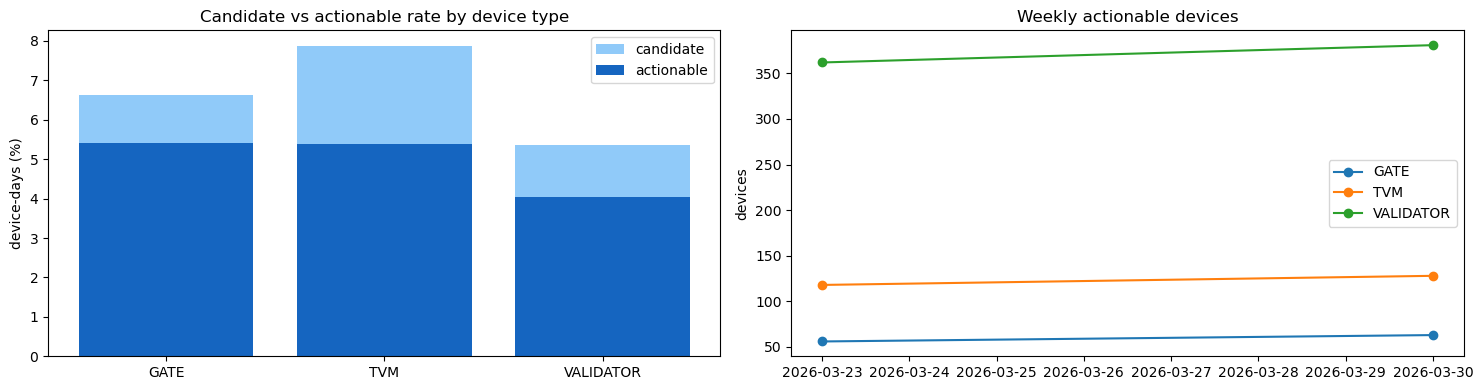

26/07/28 21:36:32 WARN DAGScheduler: Broadcasting large task binary with size 1167.9 KiB
26/07/28 21:36:32 WARN DAGScheduler: Broadcasting large task binary with size 1159.2 KiB


26/07/28 21:36:38 WARN DAGScheduler: Broadcasting large task binary with size 1167.9 KiB
26/07/28 21:36:38 WARN DAGScheduler: Broadcasting large task binary with size 1149.4 KiB


{
  "source_device_hour_rows": 14817096,
  "source_devices": 4415,
  "daily_device_days": 1378376,
  "weekly_rows": 7742,
  "weekly_alert_rows": 1108
}


In [13]:
# CELL 12 — Small dashboard data only; no full-frame .toPandas()
dashboard_rates = rate_by_type.toPandas()
dashboard_timeline = weekly_timeline.orderBy("week_start", "device_type").toPandas()

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
if len(dashboard_rates):
    axes[0].bar(dashboard_rates["device_type"], dashboard_rates["candidate_rate"] * 100, label="candidate", color="#90CAF9")
    axes[0].bar(dashboard_rates["device_type"], dashboard_rates["actionable_rate"] * 100, label="actionable", color="#1565C0")
    axes[0].set_title("Candidate vs actionable rate by device type")
    axes[0].set_ylabel("device-days (%)")
    axes[0].legend()
if len(dashboard_timeline):
    for device_type, part in dashboard_timeline.groupby("device_type"):
        axes[1].plot(pd.to_datetime(part["week_start"]), part["actionable_devices"], marker="o", label=device_type)
    axes[1].set_title("Weekly actionable devices")
    axes[1].set_ylabel("devices")
    axes[1].legend()
plt.tight_layout()
plt.show()

summary_metrics = {
    "source_device_hour_rows": source_profile["device_hour_rows"],
    "source_devices": source_profile["devices"],
    "daily_device_days": daily_profile["device_days"],
    "weekly_rows": weekly_summary.count(),
    "weekly_alert_rows": weekly_alerts.count(),
}
print(json.dumps(summary_metrics, default=str, indent=2))
log_mlflow_metrics(summary_metrics, {"run_id": RUN_ID, "pipeline_version": PIPELINE_VERSION, "cluster_features": CLUSTER_FEATURES})


## Lambda → RDS operating contract

1. Configure the S3 event on the `READY.json` suffix under this pipeline
   version. Do not trigger the Lambda for each Parquet file.
2. The Lambda reads the manifest, processes `weekly_device_summary` and
   `weekly_alerts` for only the named run, and uses the documented
   `rds_upsert_key` for idempotent batch UPSERTs.
3. Keep a processed `run_id` record in RDS. S3 events can be duplicated.
4. Use a Glue/Batch job, not Lambda, for an initial full historical
   backfill. Normal incremental runs are intentionally only 1–2 closed
   weeks and are small enough for a Lambda batch.
5. Retain old versioned runs with a separate lifecycle policy. Do not
   delete or overwrite prior S3 output during scoring.
